In [1]:
from local import *

from scipy.optimize import curve_fit
from sklearn.metrics import r2_score

from everest.window import Canvas, DataChannel as Channel
from everest import window

## Varying curvature

In [2]:
isomixed, isointernal, arrmixed, arrinternal = make_frames(refresh=True)

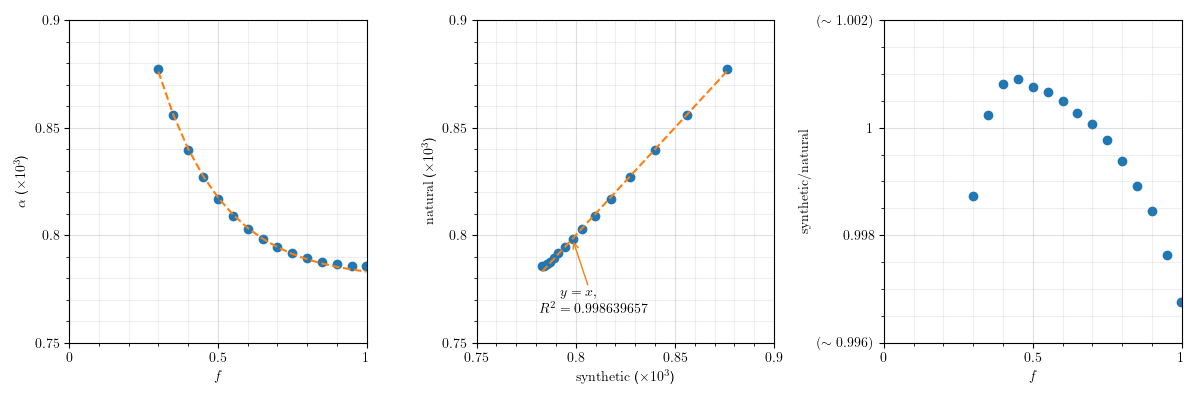

In [40]:
slc = isomixed.loc[0, 1]

canvas = Canvas(size=(12, 4), shape=(1, 3))

def model(x, /, a, b, c):
    return a * b**(x - c) + 8*math.pi**4
(*params,), error = curve_fit(model, slc.index, slc.values)
params = dict(zip('abc', (map(float, params))))
synthetic = model(slc.index, **params)
natural = slc.values
linscore = r2_score(synthetic, natural)

synth_colour = 'tab:orange'

ax1 = canvas.make_ax((0, 0))

xchan = Channel(
    slc.index, label=r"$f$",
    lims=(None, 1.), capped=(None, True),
    )
ax1.scatter(
    xchan,
    Channel(
        natural, label=r"$\alpha$",
        ),
    )
ax1.line(
    xchan,
    Channel(
        synthetic,
        ),
    color=synth_colour,
    linestyle='--',
    )

ax2 = canvas.make_ax((0, 1))

ax2.scatter(
    Channel(synthetic, label=r"$\mathrm{synthetic}$"),
    Channel(natural, label=r"$\mathrm{natural}$"),
    )

ax2.line(
    vals := np.linspace(np.min(synthetic), np.max(synthetic), 10), vals,
    color = synth_colour, linestyle = '--',
    )
ax2.annotate(
    *(map(np.median, (synthetic, natural))),
    label = f"${r'y=x, \\ R^2 =' + str(round(linscore, 10))}$",
    points = (15, -45),
    arrowprops = dict(arrowstyle = "->", color = synth_colour),
    )

ax3 = canvas.make_ax((0, 2))

ax3.scatter(
    xchan,
    Channel(
        synthetic / natural, label=r"$\mathrm{synthetic} / \mathrm{natural}$",
        )
    )


canvas

## Varying aspect ratio

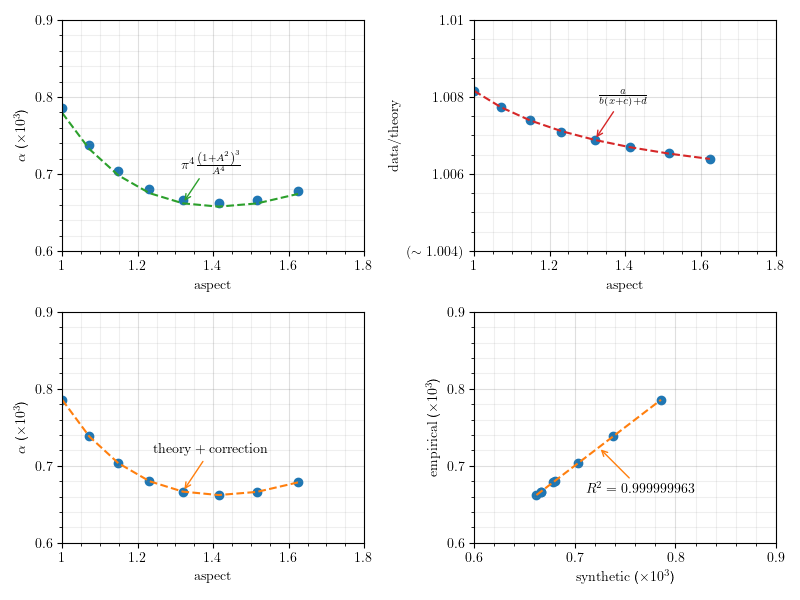

{'a': 0.0015641855292669947,
 'b': 1.2260029229767762,
 'c': -0.5719692716286624,
 'd': 1.005176453390584}

In [39]:
slc = isomixed.loc[0, :, 0.999]
# slc = arrmixed[0, :, 1., 0.999]

crit_func = lambda A: math.pi**4 * (1 + A**2)**3 / A**4
independent = slc.index
empirical = slc.values
theory = tuple(map(crit_func, slc.index))
discrepancy = empirical / theory

canvas = Canvas(size = (8, 6), shape = (2, 2))

synth_colour = 'tab:orange'

ax1 = canvas.ax((0, 0))
ax1.scatter(
    xchan := Channel(
        independent, label=r"$\mathrm{aspect}$",
        ),
    ychan := Channel(empirical, label=r"$\alpha$", log=False),
    )
ax1.line(
    xchan,
    Channel(theory, log=False),
    linestyle='--',
    color="tab:green"
    )
midpoint = round(len(theory) / 2)
ax1.annotate(
    xchan.data[midpoint], theory[midpoint],
    label = r"$\pi^4 \frac{{\left(1+A^2\right)}^3}{A^4}$",
    points = (20, 30),
    arrowprops = dict(arrowstyle = "->", color = "tab:green"),
    )

# ax1.props.edges.x.label.visible = False
# ax1.props.edges.x.ticks.major.labels = ()
# ax1.props.edges.x.swap()
# ax1.props.edges.x.ticks.major.labels[:] = []

def func(x, /, a, b, c, d):
    return a / (b*(x + c)) + d
(*params,), error = curve_fit(func, slc.index, discrepancy)
params = dict(zip('abcd', (map(float, params))))

correction = func(slc.index, **params)

ax2 = canvas.ax((0, 1))
ax2.scatter(
    xchan,
    Channel(discrepancy, label=r'$\mathrm{data} / \mathrm{theory}$'),
    )
ax2.line(
    xchan,
    Channel(correction),
    linestyle='--',
    color="tab:red",
    )
ax2.annotate(
    xchan.data[midpoint], correction[midpoint],
    # label = f"$ \\frac{{ {params['a']} }}{{ {params['b']} \\left( x + {params['c']} \\right) }} + {params['d']} $",
    label = r"$\frac{a}{b \left(A+c\right) + d}$",
    points = (20, 30),
    arrowprops = dict(arrowstyle = "->", color = "tab:red"),
    )

# ax2.props.edges.x.label.visible = False
# ax2.props.edges.x.ticks.major.labels = ()

synthetic = theory * correction

ax3 = canvas.ax((1, 0))
ax3.scatter(
    xchan,
    ychan,
    )
ax3.line(
    xchan,
    Channel(synthetic, log=False),
    linestyle='--',
    color=synth_colour,
    )
ax3.annotate(
    xchan.data[midpoint], synthetic[midpoint],
    label = r"$\mathrm{theory} + \mathrm{correction}$",
    points = (20, 30),
    arrowprops = dict(arrowstyle = "->", color = synth_colour),
    )

ax4 = canvas.ax((1, 1))
ax4.scatter(
    Channel(synthetic, label=r"$\mathrm{synthetic}$"),
    Channel(empirical, label=r"$\mathrm{empirical}$"),
    )
linscore = r2_score(synthetic, empirical)
ax4.line(
    Channel(np.linspace(min(synthetic), max(synthetic), 100)),
    Channel(np.linspace(min(empirical), max(empirical), 100)),
    linestyle = '--',
    color=synth_colour,
    )
ax4.annotate(
    *map(window.utilities.median, (synthetic, empirical)),
    label = f"${'R^2 =' + str(round(linscore, 9))}$",
    points = (30, -30),
    arrowprops = dict(arrowstyle = "->", color = synth_colour),
    )

display(canvas)
display(params)

In [29]:
print(f"\\ asdf{1}{{{2}")

\ asdf1{2


In [9]:
xchan.data

array([1.        , 1.07177346, 1.14869835, 1.23114441, 1.31950791,
       1.41421356, 1.51571657, 1.62450479])

In [22]:
min(synthetic) + (max(synthetic) - min(synthetic)) / 2

723.7701707095896

In [20]:
max(synthetic)

785.6293940427088

In [21]:
min(synthetic)

661.9109473764704

In [23]:
slc

aspect
0.500000    4413.546104
0.535887    3373.661240
0.574349    2666.292786
0.615572    2167.295211
0.659754    1799.387691
0.707107    1523.412171
0.757858    1311.889865
0.812252    1149.142845
0.870551    1023.078329
0.933033     925.462139
1.000000     785.620241
1.071773     738.011241
1.148698     703.336392
1.231144     679.864766
1.319508     666.350716
1.414214     661.906959
1.515717     665.992214
1.624505     678.320538
1.741101     734.539710
1.866066     763.673684
2.000000     802.219714
2.143547     850.555224
2.297397     909.717146
2.462289     980.682923
2.639016    1064.777948
2.828427    1163.562247
3.031433    1278.890707
3.249010    1413.064424
3.482202    1568.407385
3.732132    1748.120217
4.000000    1955.668947
Name: alpha, dtype: float64

In [28]:
tuple(2.**(val / 10) for val in range(0, 11))

(1.0,
 1.0717734625362931,
 1.148698354997035,
 1.2311444133449163,
 1.3195079107728942,
 1.4142135623730951,
 1.515716566510398,
 1.624504792712471,
 1.7411011265922482,
 1.8660659830736148,
 2.0)

## Varying heat input

In [ ]:
isointernal

In [ ]:
slc = isointernal.loc[:, 1., 0.999]

In [ ]:
canvas = Canvas(size=(4, 4))

ax1 = canvas.make_ax()

ax1.line(
    Channel(slc.index, label='$H$'),
    Channel(slc.values, label=r'$\alpha$'),
    )

canvas

In [ ]:
round(len(synthetic) / 2)

In [ ]:
len(synthetic)

In [ ]:
synthetic